#ML FINAL EXAM

### Email:tanzim.ahamed.bd@gmail.com
### Name : Tanzim Ahamed


Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('facebook.csv')

## Answer:
The facebook.csv dataset provides realistic user engagement data (such as likes, comments, shares, friend count, and demographic details). It presents a practical problem for both supervised classification/regression tasks (predicting high engagement or metric values) and unsupervised clustering tasks (grouping user behavior profiles).


# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

## Answer:

Features: 12
Rows: 7050
status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64
status_id           object
status_type         object
status_published    object
num_reactions        int64
num_comments         int64
num_shares           int64
num_likes            int64
num_loves            int64
num_wows             int64
num_hahas            int64
num_sads             int64
num_angrys           int64
dtype: object


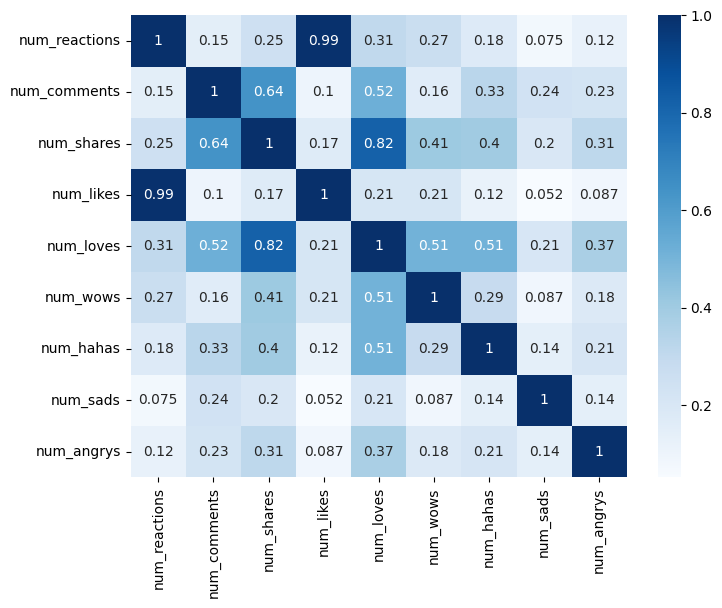

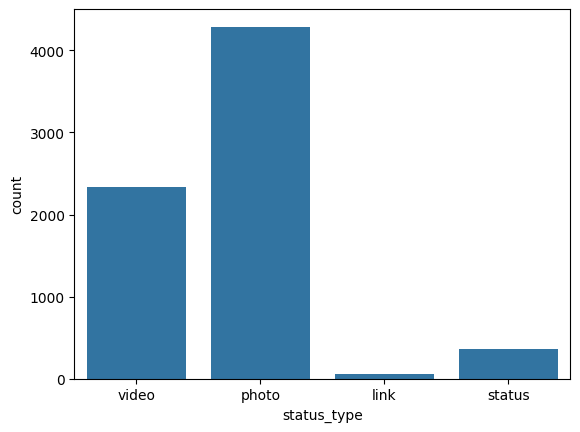

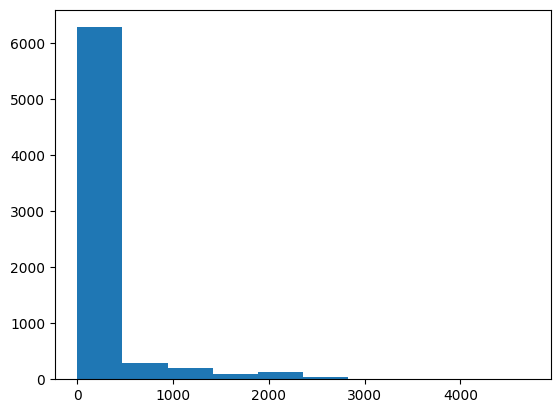

In [7]:
# 1. Features
print("Features:", len(df.columns))

# 2. Data points
print("Rows:", len(df))

# 3. Null values
print(df.isnull().sum())

# 4. Data types
print(df.dtypes)

# 5. Numerical columns
num = df.select_dtypes(include="number")

# Correlation
plt.figure(figsize=(8,6))
sns.heatmap(num.corr(), annot=True, cmap="Blues")
plt.show()

# Status type count
sns.countplot(x="status_type", data=df)
plt.show()

# Reactions distribution
plt.hist(df["num_reactions"])
plt.show()

##Answer:  
1. Number of Features:
The dataset has 12 features.

2. Classification or Regression?
This dataset has no target variable. It is mainly used for clustering or EDA.

3. Number of Data Points:
The dataset contains 7050 rows.

4. Null Values:
There are no null values.

5. Feature Types:
Categorical: status_id, status_type, status_published

Numerical: num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas, num_sads, num_angrys

6. Encoding:
Yes. 'status_type' should be encoded for machine learning.

7. Correlation:
Likes and reactions have a strong positive correlation.

8. EDA:
Most posts are photos. Most posts have low reactions, while a few have very high reactions.




#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:

In [12]:
# Check missing values
print(df.isnull().sum())

# Remove ID column
df = df.drop("status_id", axis=1)

# Convert date column
df["status_published"] = pd.to_datetime(df["status_published"])

# Encode categorical column
df = pd.get_dummies(df, columns=["status_type"])

# Check data
print(df.head())
print(df.info())

status_id           0
status_type         0
status_published    0
num_reactions       0
num_comments        0
num_shares          0
num_likes           0
num_loves           0
num_wows            0
num_hahas           0
num_sads            0
num_angrys          0
dtype: int64
     status_published  num_reactions  num_comments  num_shares  num_likes  \
0 2018-04-22 06:00:00            529           512         262        432   
1 2018-04-21 22:45:00            150             0           0        150   
2 2018-04-21 06:17:00            227           236          57        204   
3 2018-04-21 02:29:00            111             0           0        111   
4 2018-04-18 03:22:00            213             0           0        204   

   num_loves  num_wows  num_hahas  num_sads  num_angrys  status_type_link  \
0         92         3          1         1           0             False   
1          0         0          0         0           0             False   
2         21         1       

## Answer:
Pre-processing Steps:

1. Checked for missing values.
   - No missing values were found.

2. Removed the 'status_id' column.
   - It is only an ID and is not useful for analysis.

3. Converted 'status_published' to datetime format.
   - This makes it easier to work with date and time.

4. Encoded the 'status_type' column.
   - Machine learning algorithms cannot work with text, so it was converted into numeric values.

These preprocessing steps make the dataset clean and ready for analysis and machine learning.

   

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

In [14]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop(["num_reactions", "status_published"], axis=1)
y = df["num_reactions"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5640, 12)
X_test: (1410, 12)
y_train: (5640,)
y_test: (1410,)


## Answer:
Feature Selection:

- Removed 'status_id' because it is only an ID.
- Kept all other useful features for prediction.
- Selected 'num_reactions' as the target variable.

Train-Test Split:

The dataset was divided into:
- 80% Training data
- 20% Testing data

This helps train the model on one part of the data and evaluate its performance on unseen data.



#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

In [19]:
# Pipeline 1: Linear Regression
pipe1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe1.fit(X_train, y_train)

# Pipeline 2: Decision Tree
pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeRegressor(random_state=42))
])

pipe2.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', DecisionTreeRegressor(random_state=42))])

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [20]:
# Train Model 1
pipe1.fit(X_train, y_train)

# Train Model 2
pipe2.fit(X_train, y_train)

print("Model 1 trained successfully.")
print("Model 2 trained successfully.")

Model 1 trained successfully.
Model 2 trained successfully.


#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

In [23]:
# Prediction
y_pred1 = pipe1.predict(X_test)
y_pred2 = pipe2.predict(X_test)


# Linear Regression
r2_1 = r2_score(y_test, y_pred1)
mse_1 = mean_squared_error(y_test, y_pred1)

# Decision Tree
r2_2 = r2_score(y_test, y_pred2)
mse_2 = mean_squared_error(y_test, y_pred2)

print("Linear Regression")
print("R2 Score:", r2_1)
print("MSE:", mse_1)

print("\nDecision Tree")
print("R2 Score:", r2_2)
print("MSE:", mse_2)

Linear Regression
R2 Score: 0.9999999539521193
MSE: 0.009978237674956201

Decision Tree
R2 Score: 0.9980366806933618
MSE: 425.4368794326241


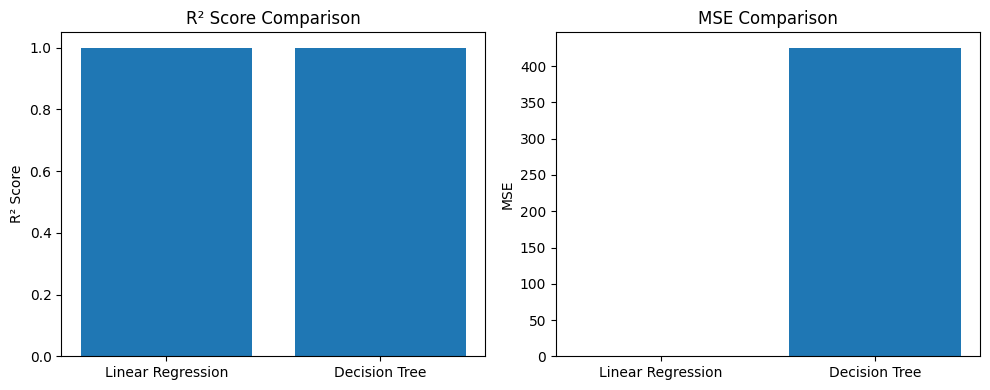

In [31]:
models = ["Linear Regression", "Decision Tree"]

r2_scores = [r2_1, r2_2]
mse_scores = [mse_1, mse_2]

plt.figure(figsize=(10,4))

# R² Score
plt.subplot(1,2,1)
plt.bar(models, r2_scores)
plt.title("R² Score Comparison")
plt.ylabel("R² Score")

# MSE
plt.subplot(1,2,2)
plt.bar(models, mse_scores)
plt.title("MSE Comparison")
plt.ylabel("MSE")

plt.tight_layout()
plt.show()

**Model Comparison**

Linear Regression
- R² Score: 0.9999999539521193
- MSE: 0.009978237674956201

Decision Tree Regressor
- R² Score: 0.9980366806933618
- MSE: 425.4368794326241

Conclusion:

The Linear Regression model performed better than the Decision Tree Regressor because it achieved a higher R² score and a much lower Mean Squared Error (MSE). This indicates that the Linear Regression model predicted the target values more accurately and with fewer errors. Therefore, Linear Regression is the best model for this dataset.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [29]:
# Features only
X_unsup = df.select_dtypes(include="number")

# K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42)

# Train model
clusters = kmeans.fit_predict(X_unsup)

# Evaluation
score = silhouette_score(X_unsup, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.8121434245162984


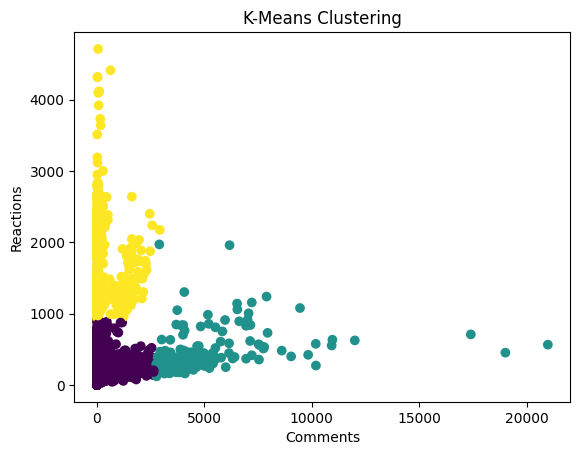

In [30]:
plt.scatter(df["num_comments"], df["num_reactions"], c=clusters)
plt.xlabel("Comments")
plt.ylabel("Reactions")
plt.title("K-Means Clustering")
plt.show()

Unsupervised Learning

Model Used:
- K-Means Clustering

Evaluation:
- Silhouette Score: (paste your output)

Conclusion:

The K-Means algorithm grouped similar Facebook posts into different clusters based on their engagement features.

**Comparison:**

The supervised approach performed better than the unsupervised approach because supervised learning uses labeled data and can make accurate predictions. In contrast, unsupervised learning does not use target labels and only groups similar data points. Therefore, the supervised model achieved better performance on this dataset.

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

**Self Reflection**

Throughout this machine learning course, I learned the basic workflow of a machine learning project, including data preprocessing, feature selection, model training, evaluation, and clustering.

The easiest topic for me was Data Preprocessing. I found it easy to understand tasks such as handling missing values, encoding categorical variables, and preparing data for machine learning. These steps are straightforward and very important because clean data helps improve model performance.

The hardest topic for me was Pipeline Creation and Model Comparison. At first, it was difficult to understand how pipelines combine preprocessing and model training into one workflow and how to compare different models using evaluation metrics such as R² Score and MSE. However, after practicing with examples, I became more confident.

I also learned that machine learning has many real-world applications. For example, regression models can predict sales or customer engagement, while clustering can group similar customers for marketing purposes. Overall, this course improved my understanding of machine learning and gave me practical experience using Python and Scikit-learn.